In [26]:
# Import the time library to track how long the search takes
import time

# --- Step 1: Define the graph G you want to test ---
# Use one of the examples from our previous discussion
# G = Graph([(0,1), (0,2), (0,3), (0,4), (0,5), (1,2), (3,4)]) # 6-vertex non-DS graph
G = graphs.CycleGraph(5) # 5-vertex DS graph

def is_ds(G) :
    print("--- Input Graph (G) ---")
    # G.show()

    # --- Step 2: Calculate invariants for G ---
    A = G.adjacency_matrix()
    n = G.order()
    e = G.size()
    t = G.triangles_count()
    walks_4 = (A**4).trace()
    # The degree sequence is a strong but optional filter
    deg = G.degree_sequence()
    # For the final verification, get the rounded spectrum of G
    g_spec = tuple(sorted([round(val, 6) for val in G.spectrum()]))

    #print(f"\nProperties of G:")
    #print(f"  - Vertices: {n}, Edges: {e}")
    #print(f"  - Triangles: {t}")
    #print(f"  - Closed 4-walks: {walks_4}")
    #print(f"  - Degree Sequence: {deg}")
    #print(f"  - Spectrum: {g_spec}\n")


    # --- Step 3: Search for candidates ---
    # print(f"Starting search through all non-isomorphic, connected graphs with {n} vertices and {e} edges...")
    start_time = time.time()

    candidates = []
    total_graphs_generated = 0
    m = e # Use 'm' as per nauty_geng's convention
    count = 0
    # The nauty_geng generator is highly efficient
    for H in graphs.nauty_geng(f"{n} -c {m}:{m}"):
        total_graphs_generated += 1
        

        # CRITICAL FIX: Skip any graph that is isomorphic to our input graph G
        #if H.is_isomorphic(G):
        #    continue

        # --- Apply Filters ---
        # Note: The edge count filter is no longer needed.

        # OPTIONAL FILTER: Degree sequence (fast, but may exclude some mates)
        # if deg!= H.degree_sequence():
        #     continue

        # SPECTRAL INVARIANT FILTERS (always safe to use)
        if t!= H.triangles_count():
            continue

        B = H.adjacency_matrix()
        if walks_4!= (B**4).trace():
            continue

        # If a graph passes all preliminary filters, add it to the candidate list
        candidates.append(H)
        count = count+1

    end_time = time.time()
    # print("Count = " , count)
    if count == 1 :
        print("\nRESULT: No non-isomorphic cospectral mates were found.")
        #print("This provides strong computational evidence that G is Determined by its Spectrum (DS).")
        print(f"K{n-1} + pendent -> is DS!")

    else :
        print(f"Search complete. Generated {total_graphs_generated} graphs in {end_time - start_time:.2f} seconds.")
        print(f"Found {len(candidates)} candidate(s) that passed all filters.\n")


    # --- Step 4: Final verification and reporting ---
        cospectral_mates = []
        if candidates:
            print("--- Verifying Full Spectra of Candidates ---")
            for H in candidates:
                h_spec = tuple(sorted([round(val, 6) for val in H.spectrum()]))
                
                # FINAL CHECK: Compare the full spectra to confirm cospectrality
                if g_spec == h_spec:
                    cospectral_mates.append(H)
                    #print("-------------------------------------------")
                    print("CONFIRMED Non-Isomorphic Cospectral Mate Found!")
                    print("Edges:", H.edges(labels=False))
                    #H.show()
                    #print(f"  - H Spectrum: {h_spec}")
                    print("-------------------------------------------")
        print(f"\nRESULT: Found {len(cospectral_mates) - 1} cospectral mate(s). G is NOT DS.")
   
        



--- Input Graph (G) ---

Properties of G:
  - Vertices: 6, Edges: 7
  - Triangles: 2
  - Closed 4-walks: 70
  - Degree Sequence: [3, 3, 3, 3, 1, 1]
  - Spectrum: (-1.903212, -1.0, -1.0, 0.193937, 1.0, 2.709275)

Starting search through all non-isomorphic, connected graphs with 6 vertices and 7 edges...
Search complete. Generated 19 graphs in 0.01 seconds.
Found 3 candidate(s) that passed all filters.

--- Verifying Full Spectra of Candidates ---
-------------------------------------------
CONFIRMED Non-Isomorphic Cospectral Mate Found!
Edges: [(0, 3), (0, 5), (1, 4), (1, 5), (2, 5), (3, 5), (4, 5)]


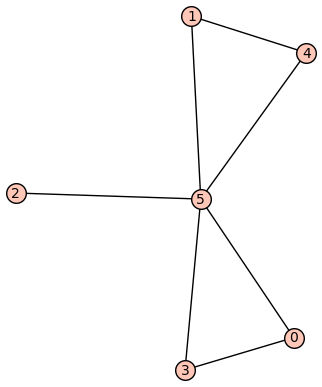

  - H Spectrum: (-1.903212, -1.0, -1.0, 0.193937, 1.0, 2.709275)
-------------------------------------------
-------------------------------------------
CONFIRMED Non-Isomorphic Cospectral Mate Found!
Edges: [(0, 3), (0, 4), (0, 5), (1, 3), (2, 4), (3, 5), (4, 5)]


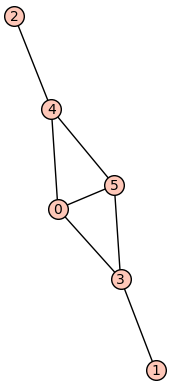

  - H Spectrum: (-1.903212, -1.0, -1.0, 0.193937, 1.0, 2.709275)
-------------------------------------------

RESULT: Found 1 cospectral mate(s). G is NOT DS.


In [13]:
# Pair of cospectral graphs on 6 vertices
G1_edges = [(0,1), (0,2), (0,3), (0,4), (0,5), (1,2), (3,4)]
G1 = Graph(G1_edges)

G2_edges = [(0,1), (1,2), (2,3), (3,4), (5,1), (5,2), (5,3)]
G2 = Graph(G2_edges)
G = G2 

is_ds(G)

In [ ]:
k1 = 14
k2 = 16
for n in range(k1,k2) :
    Kn = graphs.CompleteGraph(n)
    
    Kn.add_vertex(n)
    Kn.add_edge((0,n))

    G = Kn
    is_ds(G)
print("Finishe!")
    

--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates were found.
K5 + pendent -> is DS!
--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates were found.
K6 + pendent -> is DS!
--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates were found.
K7 + pendent -> is DS!
--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates were found.
K8 + pendent -> is DS!
--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates were found.
K9 + pendent -> is DS!
--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates were found.
K10 + pendent -> is DS!
--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates were found.
K11 + pendent -> is DS!
--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates were found.
K12 + pendent -> is DS!
--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates were found.
K13 + pendent -> is DS!
--- Input Graph (G) ---

RESULT: No non-isomorphic cospectral mates w

KeyboardInterrupt: 